<a href="https://colab.research.google.com/github/gainirajkumar39-python/ml-training-internship/blob/main/Healthcare%20Cost%20Prediction%20and%20High-Cost%20Claim%20Analytics%20Using%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Libraries

In [53]:
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
# Metrics
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score,
accuracy_score,
classification_report,
confusion_matrix
)
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


# Load Dataset

In [54]:
df = pd.read_csv("/content/MUP_INP_RY24_P04_V10_DY20_Prv.csv")

# View First Rows

In [55]:
print(df.head())


                          Rndrng_Prvdr_Org_Name             Rndrng_Prvdr_St  \
0  10001        SOUTHEAST HEALTH MEDICAL CENTER      1108 ROSS CLARK CIRCLE   
1  10005  MARSHALL MEDICAL CENTERS SOUTH CAMPUS  2505 U S HIGHWAY 431 NORTH   
2  10006           NORTH ALABAMA MEDICAL CENTER         1701 VETERANS DRIVE   
3  10007               MIZELL MEMORIAL HOSPITAL               702 N MAIN ST   
4  10008            CRENSHAW COMMUNITY HOSPITAL         101 HOSPITAL CIRCLE   

  Rndrng_Prvdr_City  Rndrng_Prvdr_Zip5 Rndrng_Prvdr_State_Abrvtn  \
0            DOTHAN              36301                        AL   
1              BOAZ              35957                        AL   
2          FLORENCE              35630                        AL   
3               OPP              36467                        AL   
4           LUVERNE              36049                        AL   

   Rndrng_Prvdr_State_FIPS  Rndrng_Prvdr_RUCA  \
0                        1                1.0   
1                 

# Dataset Shape

In [56]:
print("Dataset Shape:", df.shape)


Dataset Shape: (3156, 57)


# Column Names

In [57]:
print(df.columns.tolist())


['    ', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Tot_Benes', 'Tot_Submtd_Cvrd_Chrg', 'Tot_Pymt_Amt', 'Tot_Mdcr_Pymt_Amt', 'Tot_Dschrgs', 'Tot_Cvrd_Days', 'Tot_Days', 'Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_API_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_NatInd_Cnt', 'Bene_Race_Othr_Cnt', 'Bene_Dual_Cnt', 'Bene_Ndual_Cnt', 'Bene_CC_BH_ADHD_OthCD_V1_Pct', 'Bene_CC_BH_Alcohol_Drug_V1_Pct', 'Bene_CC_BH_Tobacco_V1_Pct', 'Bene_CC_BH_Alz_NonAlzdem_V2_Pct', 'Bene_CC_BH_Anxiety_V1_Pct', 'Bene_CC_BH_Bipolar_V1_Pct', 'Bene_CC_BH_Mood_V2_Pct', 'Bene_CC_BH_Depress_V1_Pct', 'Bene_CC_BH_PD_V1_Pct', 'Bene_CC_BH_PTSD_V1_Pct', 'Bene_CC_BH_Schizo_OthPsy_V1_Pct', 'Bene_CC_PH_Asthma_V2_Pct', 'Bene_CC_PH_Afib_V2_P

# Dataset Information

In [58]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3156 entries, 0 to 3155
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0                                     3156 non-null   int64  
 1   Rndrng_Prvdr_Org_Name             3156 non-null   object 
 2   Rndrng_Prvdr_St                   3156 non-null   object 
 3   Rndrng_Prvdr_City                 3156 non-null   object 
 4   Rndrng_Prvdr_Zip5                 3156 non-null   int64  
 5   Rndrng_Prvdr_State_Abrvtn         3156 non-null   object 
 6   Rndrng_Prvdr_State_FIPS           3156 non-null   int64  
 7   Rndrng_Prvdr_RUCA                 3156 non-null   float64
 8   Rndrng_Prvdr_RUCA_Desc            3156 non-null   object 
 9   Tot_Benes                         3154 non-null   float64
 10  Tot_Submtd_Cvrd_Chrg              3154 non-null   float64
 11  Tot_Pymt_Amt                      3154 non-null   float64
 12  Tot_Md

# Statistical Summary

In [59]:
print(df.describe())

                      Rndrng_Prvdr_Zip5  Rndrng_Prvdr_State_FIPS  \
count    3156.000000        3156.000000              3156.000000   
mean   261066.353612       52160.851077                28.218948   
std    161975.695275       27719.999885                15.999423   
min     10001.000000        1040.000000                 1.000000   
25%    110100.750000       30220.750000                13.000000   
50%    250053.500000       48911.000000                28.000000   
75%    390114.250000       76235.500000                42.000000   
max    670260.000000       99801.000000                56.000000   

       Rndrng_Prvdr_RUCA     Tot_Benes  Tot_Submtd_Cvrd_Chrg  Tot_Pymt_Amt  \
count        3156.000000   3154.000000          3.154000e+03  3.154000e+03   
mean            2.624810   1809.358275          1.801766e+08  4.042061e+07   
std             6.550343   1905.785426          2.876050e+08  5.672696e+07   
min             1.000000     12.000000          1.131100e+05  9.709400e+04 

In [60]:
print(df.describe())


                      Rndrng_Prvdr_Zip5  Rndrng_Prvdr_State_FIPS  \
count    3156.000000        3156.000000              3156.000000   
mean   261066.353612       52160.851077                28.218948   
std    161975.695275       27719.999885                15.999423   
min     10001.000000        1040.000000                 1.000000   
25%    110100.750000       30220.750000                13.000000   
50%    250053.500000       48911.000000                28.000000   
75%    390114.250000       76235.500000                42.000000   
max    670260.000000       99801.000000                56.000000   

       Rndrng_Prvdr_RUCA     Tot_Benes  Tot_Submtd_Cvrd_Chrg  Tot_Pymt_Amt  \
count        3156.000000   3154.000000          3.154000e+03  3.154000e+03   
mean            2.624810   1809.358275          1.801766e+08  4.042061e+07   
std             6.550343   1905.785426          2.876050e+08  5.672696e+07   
min             1.000000     12.000000          1.131100e+05  9.709400e+04 

 Missing Value Analysis


In [61]:

missing_values = df.isnull().sum()
print(missing_values)

                                       0
Rndrng_Prvdr_Org_Name                  0
Rndrng_Prvdr_St                        0
Rndrng_Prvdr_City                      0
Rndrng_Prvdr_Zip5                      0
Rndrng_Prvdr_State_Abrvtn              0
Rndrng_Prvdr_State_FIPS                0
Rndrng_Prvdr_RUCA                      0
Rndrng_Prvdr_RUCA_Desc                 0
Tot_Benes                              2
Tot_Submtd_Cvrd_Chrg                   2
Tot_Pymt_Amt                           2
Tot_Mdcr_Pymt_Amt                      2
Tot_Dschrgs                            0
Tot_Cvrd_Days                          2
Tot_Days                               2
Bene_Avg_Age                           2
Bene_Age_LT_65_Cnt                   198
Bene_Age_65_74_Cnt                    36
Bene_Age_75_84_Cnt                    59
Bene_Age_GT_84_Cnt                   217
Bene_Feml_Cnt                         35
Bene_Male_Cnt                         35
Bene_Race_Wht_Cnt                     34
Bene_Race_Black_

 Remove Missing Values

In [62]:
df = df.dropna()
print("Shape After Removing Nulls:", df.shape)


Shape After Removing Nulls: (285, 57)


 Remove Duplicate Records

In [63]:

df = df.drop_duplicates()
print("Shape After Removing Duplicates:", df.shape)


Shape After Removing Duplicates: (285, 57)


Charge Distribution

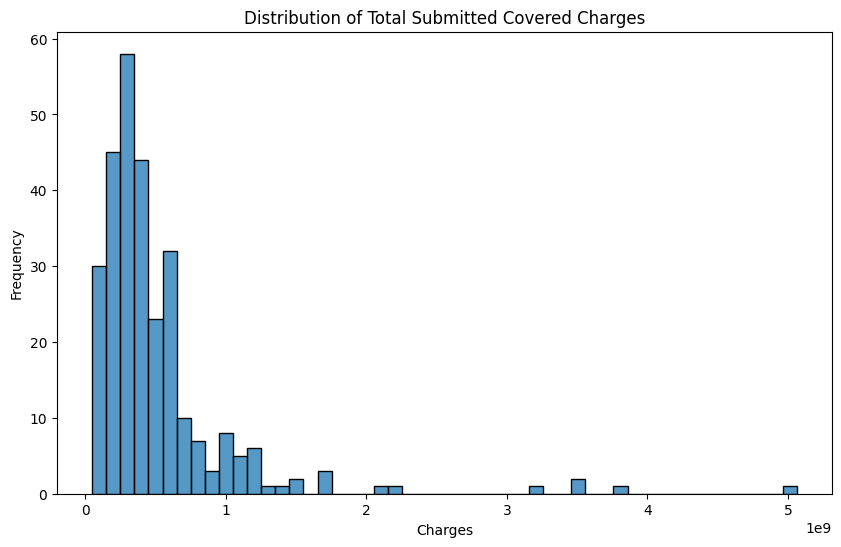

In [64]:
plt.figure(figsize=(10,6))
sns.histplot(df['Tot_Submtd_Cvrd_Chrg'], bins=50)
plt.title('Distribution of Total Submitted Covered Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()


 Top States by Healthcare Charges

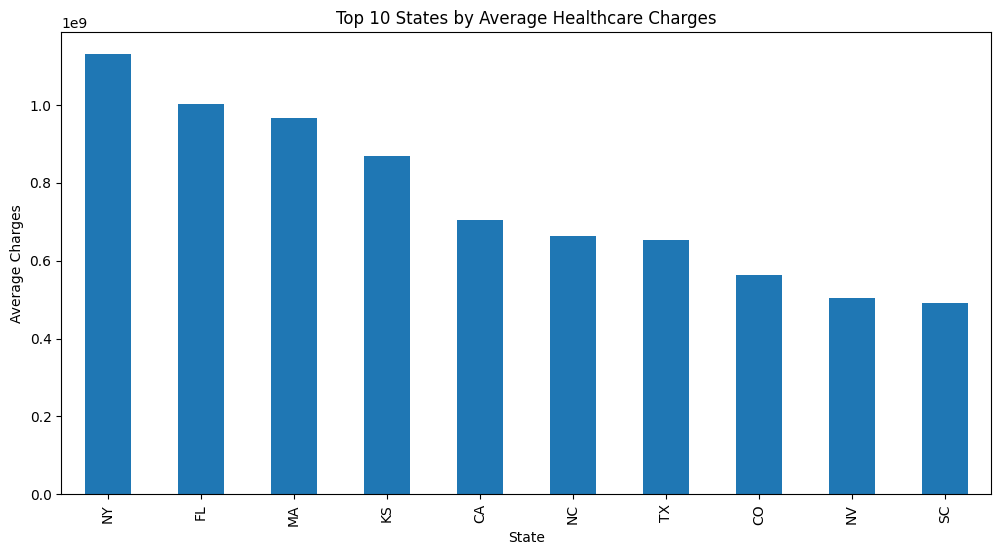

In [65]:
state_charges = df.groupby(
'Rndrng_Prvdr_State_Abrvtn'
)['Tot_Submtd_Cvrd_Chrg'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
state_charges.plot(kind='bar')
plt.title('Top 10 States by Average Healthcare Charges')
plt.xlabel('State')
plt.ylabel('Average Charges')
plt.show()

 Correlation Analysis

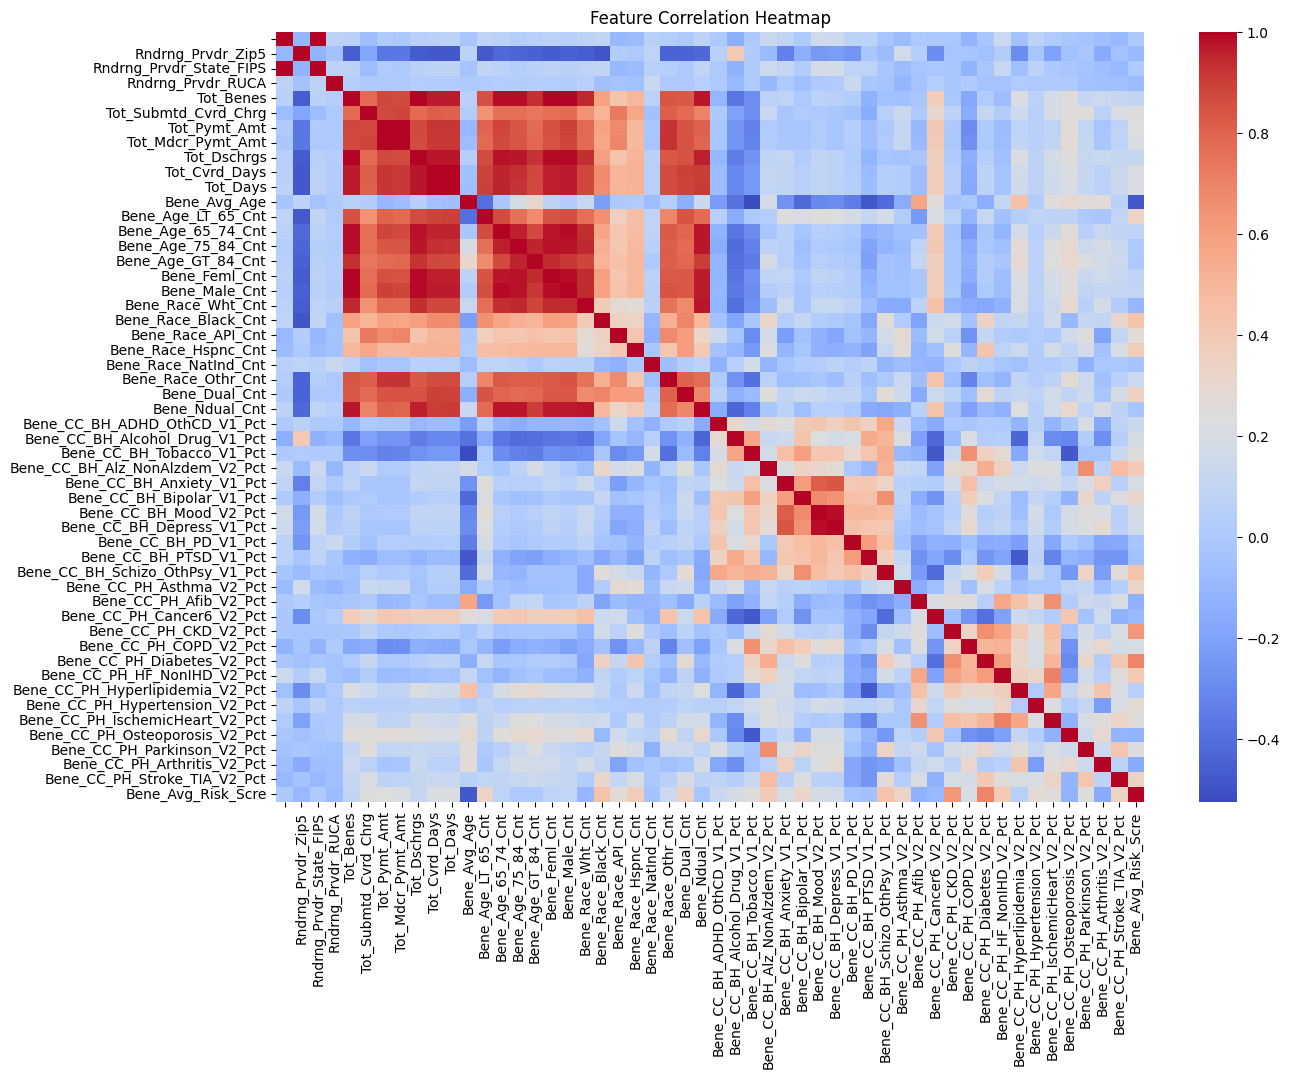

In [66]:
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


Define Target Variable

In [67]:
target_column = 'Tot_Submtd_Cvrd_Chrg'


 Encode Categorical Features

In [68]:
label_encoder = LabelEncoder()
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

Create High Cost Feature

In [69]:
median_charge = df[target_column].median()
df['HIGH_COST'] = (
df[target_column] > median_charge
).astype(int)


Feature Selection


In [70]:
X = df.drop(columns=[target_column, 'HIGH_COST'])
# Regression Target
y_reg = df[target_column]
# Classification Target
y_clf = df['HIGH_COST']


Regression Split


In [71]:
(X_train_reg,
X_test_reg,
y_train_reg,
y_test_reg) = train_test_split(
X,
y_reg,
test_size=0.2,
random_state=42
)

Classification Split

In [72]:
(X_train_clf,
X_test_clf,
y_train_clf,
y_test_clf) = train_test_split(
X,
y_clf,
test_size=0.2,
random_state=42
)

 Train Regression Model

In [73]:
reg_model = RandomForestRegressor(
n_estimators=100,
random_state=42,
n_jobs=-1
)
reg_model.fit(X_train_reg, y_train_reg)


RandomForestRegressor(n_jobs=-1, random_state=42)

Regression Predictions


In [74]:
reg_predictions = reg_model.predict(X_test_reg)


Regression Evaluation

In [75]:
mae = mean_absolute_error(y_test_reg, reg_predictions)
mse = mean_squared_error(y_test_reg, reg_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, reg_predictions)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


Mean Absolute Error: 143591472.46350875
Mean Squared Error: 5.765379020449621e+16
Root Mean Squared Error: 240112036.7755357
R2 Score: 0.8706908033714943


Actual vs Predicted Plot

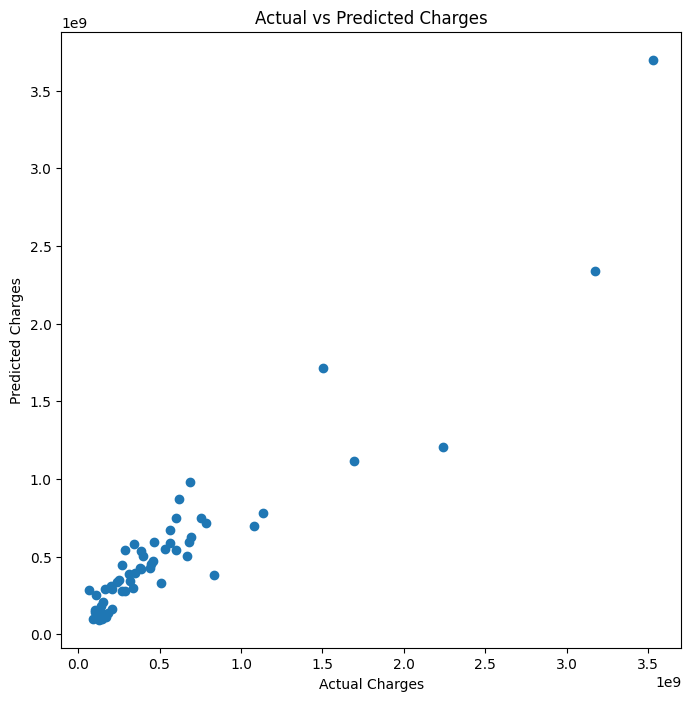

In [76]:
plt.figure(figsize=(8,8))
plt.scatter(y_test_reg, reg_predictions)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.show()

Train Classification Model



In [77]:
clf_model = RandomForestClassifier(
n_estimators=100,
random_state=42,
n_jobs=-1
)
clf_model.fit(X_train_clf, y_train_clf)

RandomForestClassifier(n_jobs=-1, random_state=42)

 Classification Predictions

In [78]:
clf_predictions = clf_model.predict(X_test_clf)

Classification Evaluation

In [79]:
accuracy = accuracy_score(
y_test_clf,
clf_predictions
)
print("Classification Accuracy:", accuracy)


Classification Accuracy: 0.8947368421052632


Classification Report

In [80]:
print(
classification_report(
y_test_clf,
clf_predictions
)
)

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        28
           1       0.87      0.93      0.90        29

    accuracy                           0.89        57
   macro avg       0.90      0.89      0.89        57
weighted avg       0.90      0.89      0.89        57



Confusion Matrix


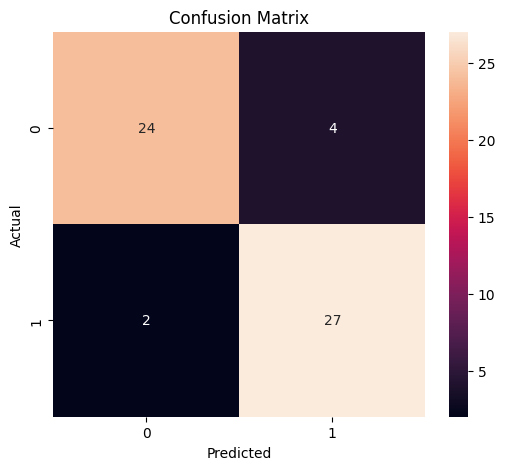

In [81]:
cm = confusion_matrix(
y_test_clf,
clf_predictions
)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Extract Feature Importance

In [82]:
importance_df = pd.DataFrame({
'Feature': X.columns,
'Importance': reg_model.feature_importances_
})
importance_df = importance_df.sort_values(
by='Importance',
ascending=False
)
print(importance_df.head(15))


                           Feature  Importance
11               Tot_Mdcr_Pymt_Amt    0.287191
24               Bene_Race_API_Cnt    0.225568
10                    Tot_Pymt_Amt    0.152136
13                   Tot_Cvrd_Days    0.038211
27              Bene_Race_Othr_Cnt    0.037665
17              Bene_Age_65_74_Cnt    0.026950
28                   Bene_Dual_Cnt    0.018032
25             Bene_Race_Hspnc_Cnt    0.015463
32       Bene_CC_BH_Tobacco_V1_Pct    0.014447
21                   Bene_Male_Cnt    0.012840
12                     Tot_Dschrgs    0.012067
51  Bene_CC_PH_Osteoporosis_V2_Pct    0.010820
54    Bene_CC_PH_Stroke_TIA_V2_Pct    0.010803
9                        Tot_Benes    0.008673
14                        Tot_Days    0.007956


Feature Importance Visualization


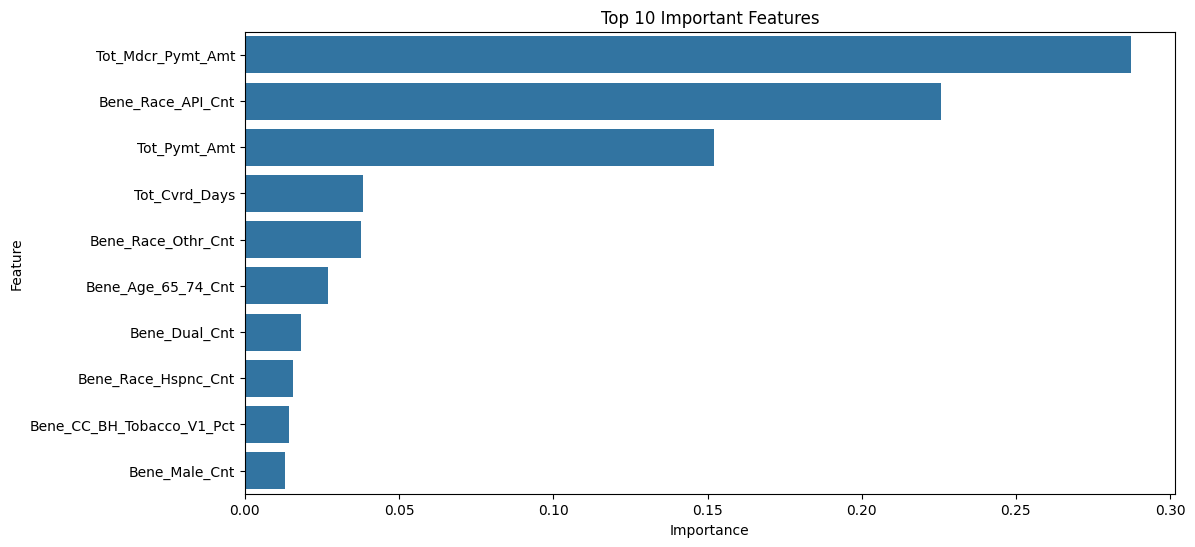

In [83]:
top_features = importance_df.head(10)
plt.figure(figsize=(12,6))
sns.barplot(
x='Importance',
 y='Feature',
data=top_features
)
plt.title('Top 10 Important Features')
plt.show()